# Quick start

In [1]:
from lightkurve import search_targetpixelfile
pixelfile = search_targetpixelfile("KIC 8462852", quarter=16).download();

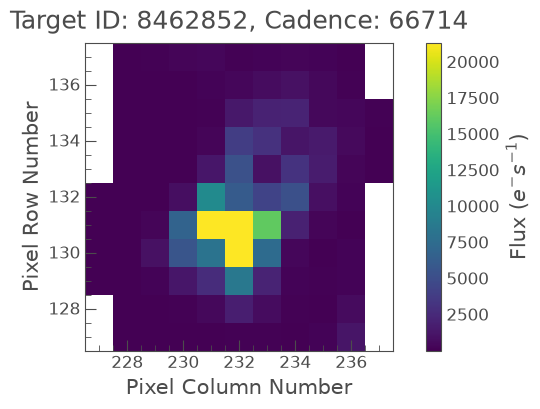

In [2]:
pixelfile.plot(frame=1);

In [3]:
lc = pixelfile.to_lightcurve(aperture_mask='all');

In [4]:
lc.time

<Time object: scale='tdb' format='bkjd' value=[1472.11777934 1472.13821223 1472.15864492 ... 1557.91762194 1557.9380561
 1557.95849016]>

In [5]:
lc.flux

<Quantity [258645.03, 258660.05, 258690.08, ..., 258948.84, 258884.66,
           258865.6 ] electron / s>

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

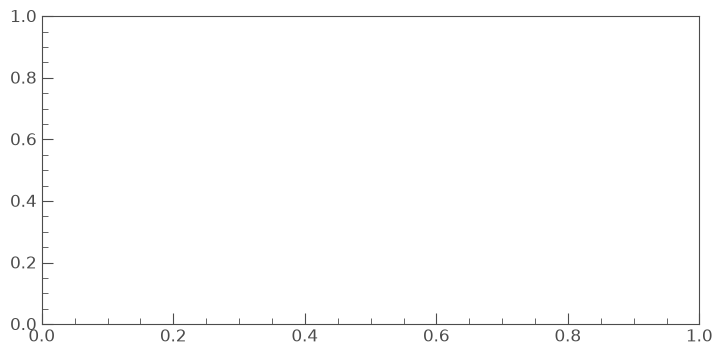

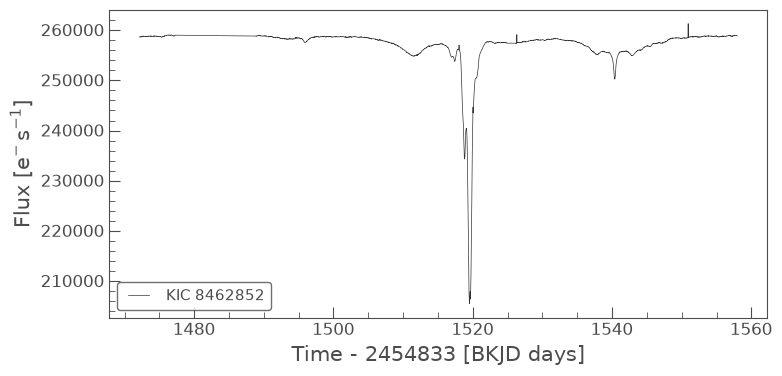

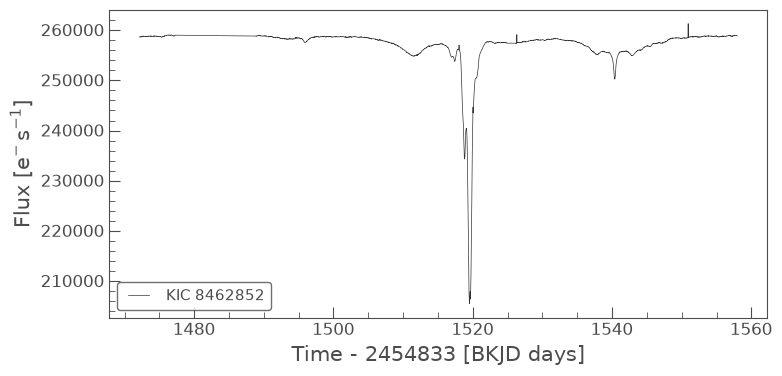

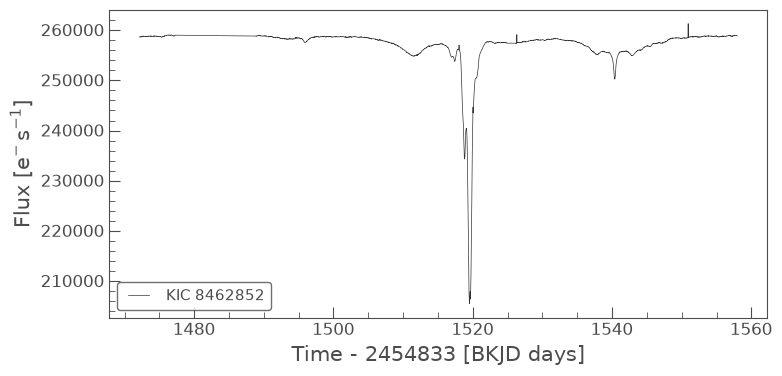

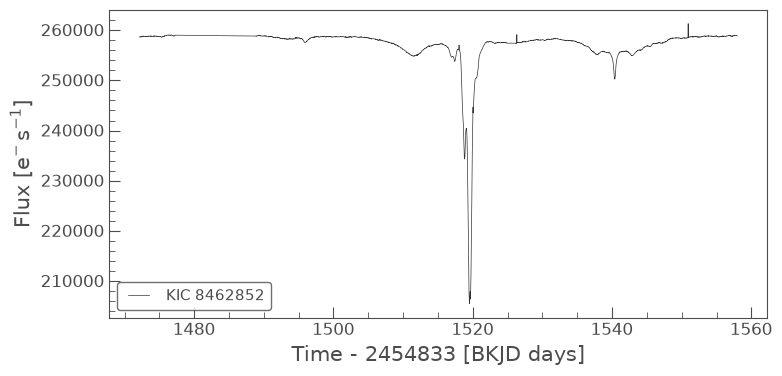

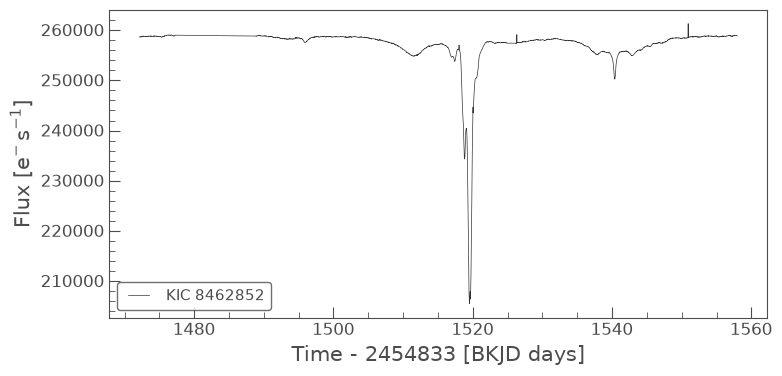

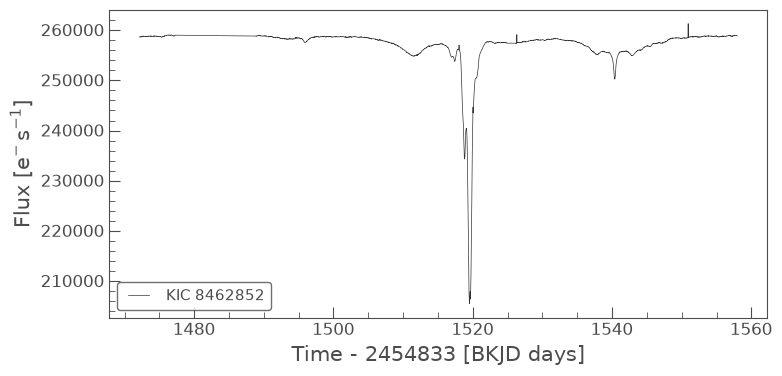

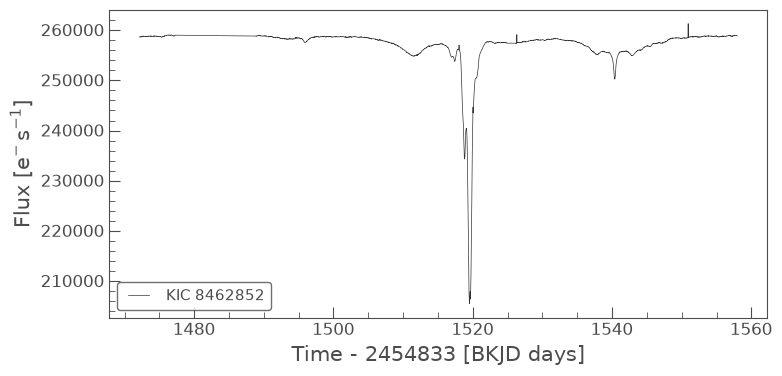

In [14]:
%matplotlib inline
lc.plot()

# The LightCurve Class

Essentially a timeseries data with brightness of star over time.

In [ ]:
%matplotlib inline
from lightkurve import search_targetpixelfile

In [15]:
tpf = search_targetpixelfile('KIC 6922244', author="Kepler", cadence="long", quarter=4).download()

# Then we convert the target pixel file into a light curve using the pipeline-defined aperture mask.
lc = tpf.to_lightcurve(aperture_mask=tpf.pipeline_mask)

In [16]:
lc.meta['MISSION']

'Kepler'

In [17]:
lc.meta['QUARTER']

4

In [18]:
lc.time

<Time object: scale='tdb' format='bkjd' value=[352.37632485 352.39675805 352.43762445 ... 442.16263546 442.18306983
 442.2035041 ]>

In [19]:
lc.flux

<Quantity [43689.15 , 43698.08 , 43694.105, ..., 43155.8  , 43148.465,
           43151.562] electron / s>

In [ ]:
lc.estimate_cdpp() # Combined Differential Photometric Precision (“CDPP”) noise metric of the lightcurve

<Quantity 75.29224609 ppm>

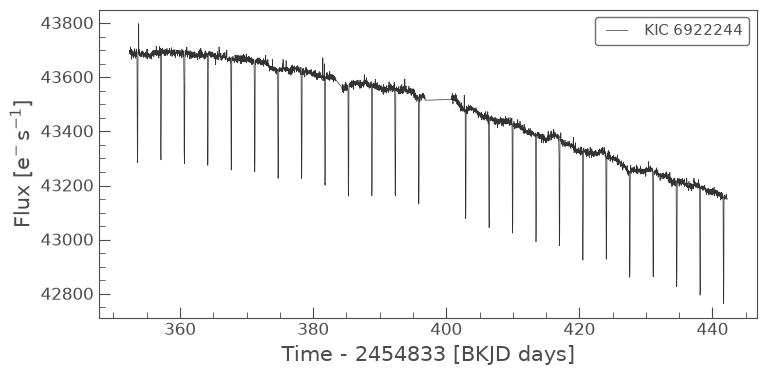

In [21]:
lc.plot();

There are a set of useful functions in LightCurve objects which you can use to work with the data. These include:

1. flatten(): Remove long term trends using a Savitzky–Golay filter

2. remove_outliers(): Remove outliers using simple sigma clipping

3. remove_nans(): Remove infinite or NaN values (these can occur during thruster firings)

4. fold(): Fold the data at a particular period

5. bin(): Reduce the time resolution of the array, taking the average value in each bin.

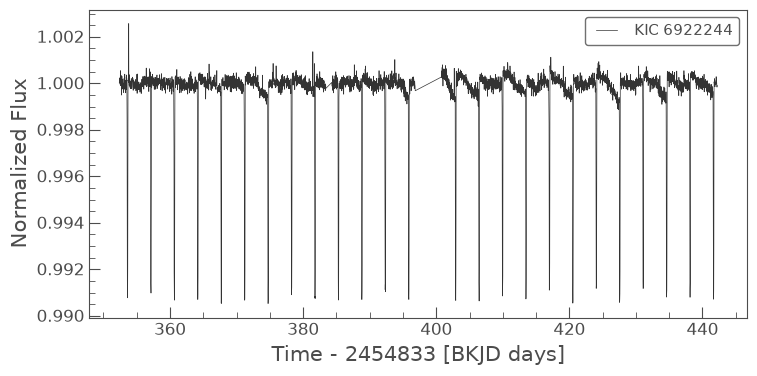

In [22]:
flat_lc = lc.flatten(window_length=401)
flat_lc.plot();

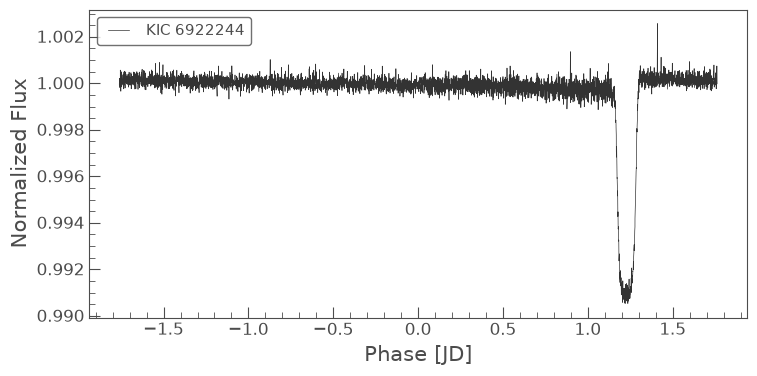

In [ ]:
folded_lc = flat_lc.fold(period=3.5225)
folded_lc.plot();

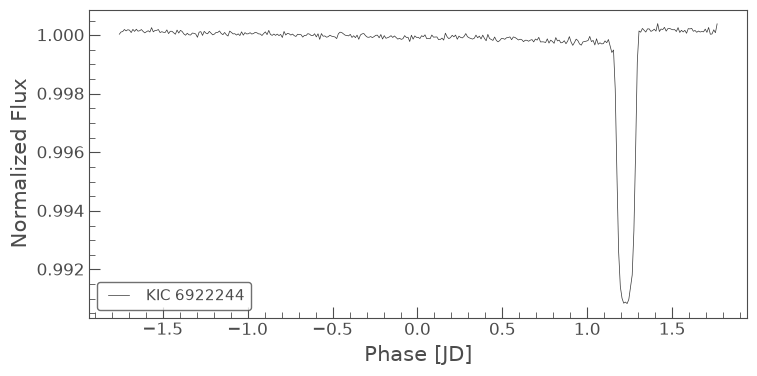

In [24]:
binned_lc = folded_lc.bin(time_bin_size=0.01)
binned_lc.plot();

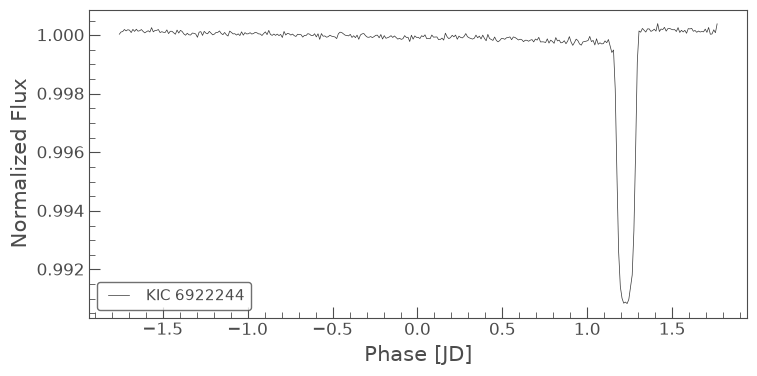

In [25]:
lc.remove_nans().flatten(window_length=401).fold(period=3.5225).bin(time_bin_size=0.01).plot();

# TargetPixelFile Class

In [26]:
%matplotlib inline
import lightkurve as lk

In [27]:

tpf = lk.read("https://archive.stsci.edu/pub/kepler/target_pixel_files/0069/006922244/kplr006922244-2010078095331_lpd-targ.fits.gz")

In [28]:
from lightkurve import search_targetpixelfile
tpf = search_targetpixelfile('KIC 6922244', author="Kepler", quarter=4, cadence="long").download()

In [29]:
tpf

KeplerTargetPixelFile Object (ID: 6922244)

In [30]:
tpf.meta['MISSION']

'Kepler'

In [31]:
tpf.meta['QUARTER']

4

In [32]:
tpf.time

<Time object: scale='tdb' format='bkjd' value=[352.37632485 352.39675805 352.43762445 ... 442.16263546 442.18306983
 442.2035041 ]>

In [36]:
tpf.time.iso #  these timestamps are in the Solar System Barycentric frame (TDB)

array(['2009-12-19 21:01:54.467', '2009-12-19 21:31:19.895',
       '2009-12-19 22:30:10.752', ..., '2010-03-19 15:54:11.704',
       '2010-03-19 16:23:37.233', '2010-03-19 16:53:02.754'],
      shape=(4116,), dtype='<U23')

In [37]:
tpf.time.utc.iso

array(['2009-12-19 21:00:48.284', '2009-12-19 21:30:13.712',
       '2009-12-19 22:29:04.569', ..., '2010-03-19 15:53:05.518',
       '2010-03-19 16:22:31.048', '2010-03-19 16:51:56.568'],
      shape=(4116,), dtype='<U23')

In [38]:
tpf.flux.shape

(4116, 5, 5)

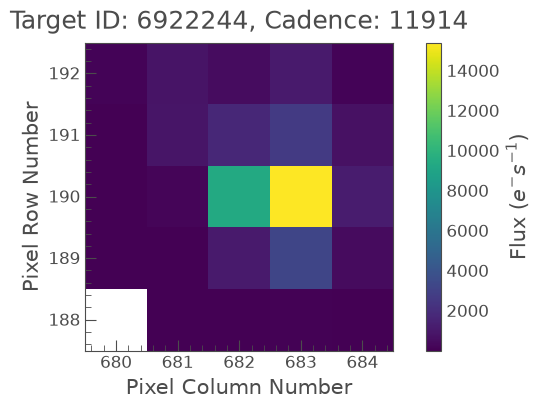

In [39]:
tpf.plot(frame=0);

In [40]:
tpf.flux[0]

<Quantity [[          nan, 5.6079335e+00, 5.1491142e+01, 8.4241745e+01,
            3.0221334e+01],
           [4.4045620e+01, 7.6861229e+01, 1.1227759e+03, 3.2262029e+03,
            4.5486777e+02],
           [2.5911165e+01, 2.2907593e+02, 9.3626543e+03, 2.3606273e+04,
            1.2087750e+03],
           [4.0100830e+01, 8.8543927e+02, 1.7102118e+03, 2.6254871e+03,
            7.0796606e+02],
           [1.5719417e+02, 8.3713440e+02, 5.1021539e+02, 1.1501041e+03,
            1.8313370e+02]] electron / s>

In [41]:
tpf.pipeline_mask

array([[False, False, False, False, False],
       [False, False,  True,  True, False],
       [False, False,  True,  True, False],
       [False,  True,  True,  True, False],
       [False, False, False,  True, False]])

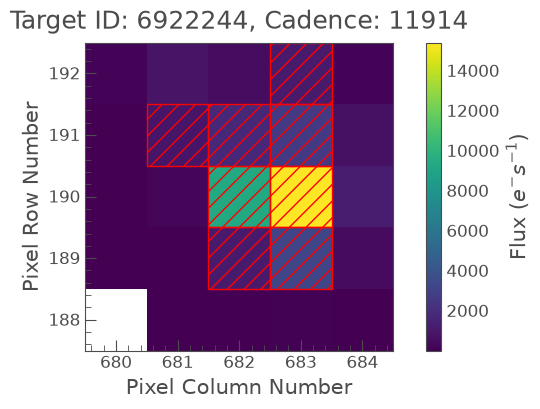

In [42]:
tpf.plot(aperture_mask=tpf.pipeline_mask);

In [43]:
tpf.get_header()[:10]

SIMPLE  =                    T / conforms to FITS standards                     
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T / file contains extensions                       
NEXTEND =                    2 / number of standard extensions                  
EXTNAME = 'PRIMARY '           / name of extension                              
EXTVER  =                    1 / extension version number (not format version)  
ORIGIN  = 'NASA/Ames'          / institution responsible for creating this file 
DATE    = '2015-09-23'         / file creation date.                            
CREATOR = '917482 TargetPixelExporterPipelineModule' / pipeline job and program 

In [44]:
tpf.hdu[1].header['TTYPE*']

TTYPE1  = 'TIME    '           / column title: data time stamps                 
TTYPE2  = 'TIMECORR'           / column title: barycenter - timeslice correction
TTYPE3  = 'CADENCENO'          / column title: unique cadence number            
TTYPE4  = 'RAW_CNTS'           / column title: raw pixel counts                 
TTYPE5  = 'FLUX    '           / column title: calibrated pixel flux            
TTYPE6  = 'FLUX_ERR'           / column title: 1-sigma calibrated uncertainty   
TTYPE7  = 'FLUX_BKG'           / column title: calibrated background flux       
TTYPE8  = 'FLUX_BKG_ERR'       / column title: 1-sigma cal. background uncertain
TTYPE9  = 'COSMIC_RAYS'        / column title: cosmic ray detections            
TTYPE10 = 'QUALITY '           / column title: pixel quality flags              
TTYPE11 = 'POS_CORR1'          / column title: column position correction       
TTYPE12 = 'POS_CORR2'          / column title: row position correction          
TTYPE13 = 'RB_LEVEL'        

# Periodogram objects

In [45]:
%matplotlib inline
from lightkurve import search_lightcurve

In [46]:
lc = search_lightcurve('KIC 10264202', author="Kepler", quarter=10, cadence="long").download().remove_nans()

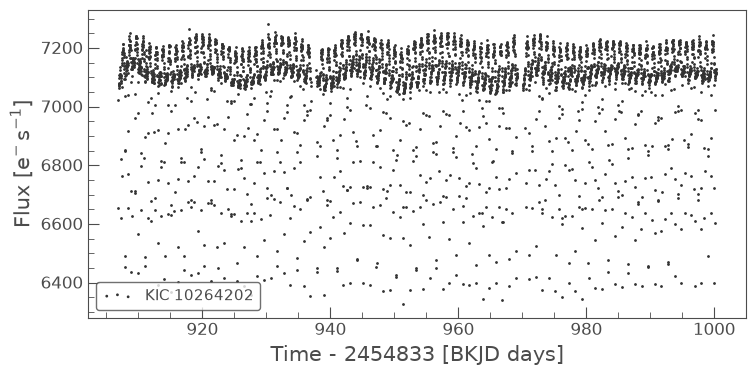

In [47]:
lc.scatter();

In [54]:
pg = lc.to_periodogram(oversample_factor=1)

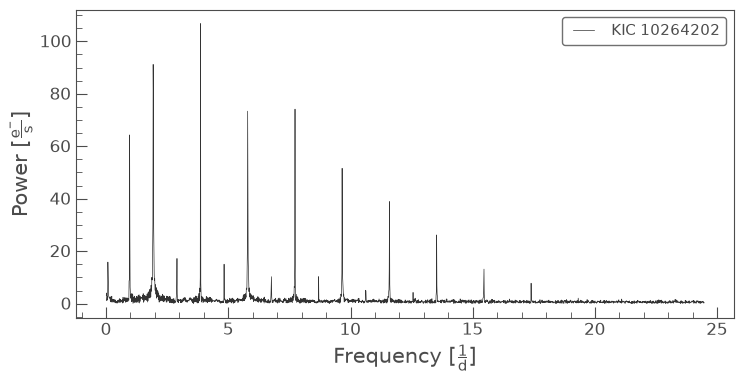

In [55]:
pg.plot();

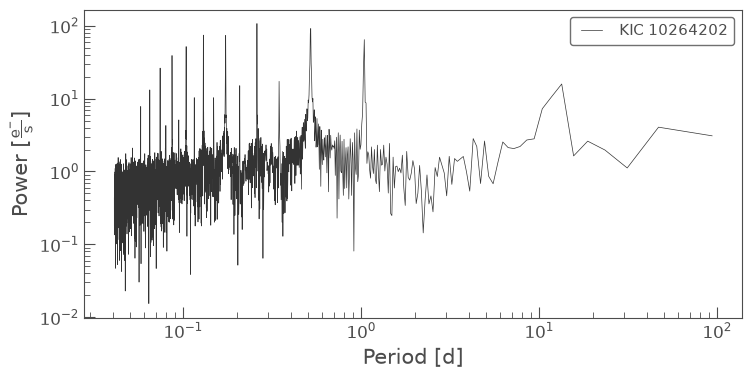

In [56]:
pg.plot(view='period', scale='log');

In [57]:
pg.period

<Quantity [9.34019490e+01, 4.67009745e+01, 3.11339830e+01, ...,
           4.09119356e-02, 4.08940232e-02, 4.08761265e-02] d>

In [58]:
pg.power

<Quantity [3.08123354, 4.04909814, 1.11686654, ..., 0.37185068, 0.17986352,
           0.43333466] electron / s>

In [59]:
pg.period_at_max_power

<Quantity 0.25873116 d>

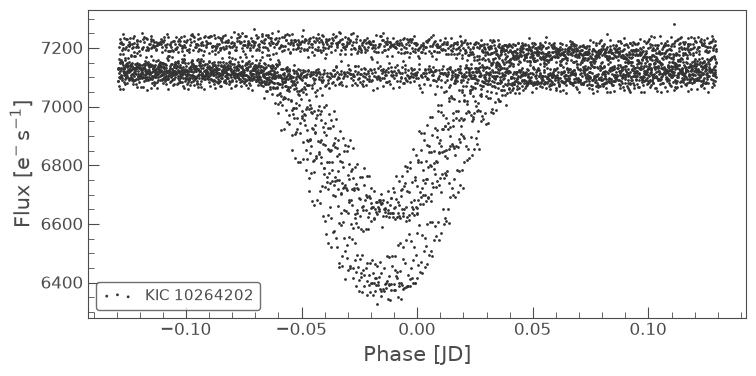

In [60]:
lc.fold(period=pg.period_at_max_power).scatter();

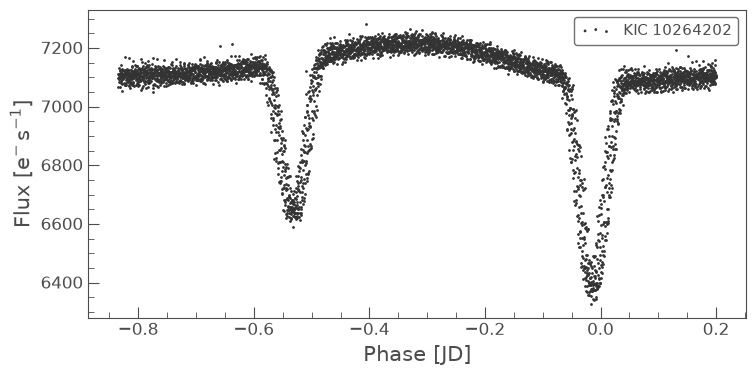

In [61]:
lc.fold(period=4*pg.period_at_max_power, wrap_phase=0.2).scatter();

In [62]:
import astropy.units as u
pg = lc.to_periodogram(minimum_period=0.9*u.day, maximum_period=1.2*u.day, oversample_factor=10)
pg.period_at_max_power

<Quantity 1.03509717 d>

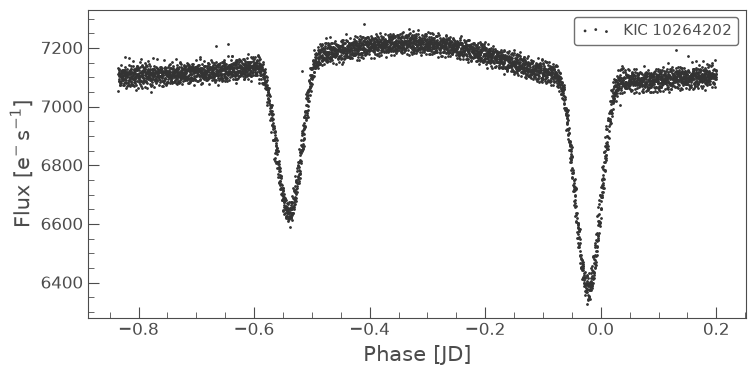

In [63]:
lc.fold(period=pg.period_at_max_power, wrap_phase=0.2).scatter();